In [5]:
import pandas as pd
import re

# 1. Load and format timestamps 
df = pd.read_csv('../data/dataset.csv')
df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')

# 2. Unpivot the matrix from Wide to Long format
# keeping datetime and underlying_price as our anchor columns
df_long = df.melt(
    id_vars=['datetime', 'underlying_price'], 
    var_name='instrument', 
    value_name='implied_volatility'
)

# 3. Extract dimensions using Regular Expressions
# Pattern: NIFTY + (Expiry: 2 digits, 3 letters, 2 digits) + (Strike: digits) + (Type: CE or PE)
regex_pattern = r'NIFTY(\d{2}[A-Z]{3}\d{2})(\d+)(CE|PE)'
extracted_cols = df_long['instrument'].str.extract(regex_pattern)
extracted_cols.columns = ['expiry', 'strike', 'option_type']

# 4. Concatenate and cast to rigorous data types
df_surface = pd.concat([df_long, extracted_cols], axis=1)
df_surface['strike'] = pd.to_numeric(df_surface['strike'])
df_surface['expiry'] = pd.to_datetime(df_surface['expiry'], format='%d%b%y')

# 5. First-Principles Feature Engineering: Moneyness (S/K)
df_surface['moneyness'] = df_surface['underlying_price'] / df_surface['strike']

# 6. Clean up the dataframe and sort mathematically by Time, then Strike
df_surface = df_surface.drop(columns=['instrument'])
df_surface = df_surface.sort_values(by=['datetime', 'strike']).reset_index(drop=True)

# 7. Output the new structural dimensions
print(f"New Tensor Dimensions: {df_surface.shape}")
print(f"Total Missing IV Values: {df_surface['implied_volatility'].isna().sum()}")
print("\nFirst 5 Rows of the Volatility Surface:")
print(df_surface.head())

New Tensor Dimensions: (27300, 7)
Total Missing IV Values: 5460

First 5 Rows of the Volatility Surface:
             datetime  underlying_price  implied_volatility     expiry  \
0 2026-01-07 09:15:00          26111.65             0.17840 2026-01-27   
1 2026-01-07 09:15:00          26111.65             0.17237 2026-01-27   
2 2026-01-07 09:15:00          26111.65             0.16928 2026-01-27   
3 2026-01-07 09:15:00          26111.65                 NaN 2026-01-27   
4 2026-01-07 09:15:00          26111.65             0.15760 2026-01-27   

   strike option_type  moneyness  
0   23800          PE   1.097128  
1   23900          PE   1.092538  
2   24000          PE   1.087985  
3   24100          PE   1.083471  
4   24200          PE   1.078994  


<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hz/vpl5_6vj4vj6bc91fj1cbjjw0000gn/T/ipykernel_31520/2202747206.py:39: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Implied Volatility ($\sigma$)', fontsize=12)


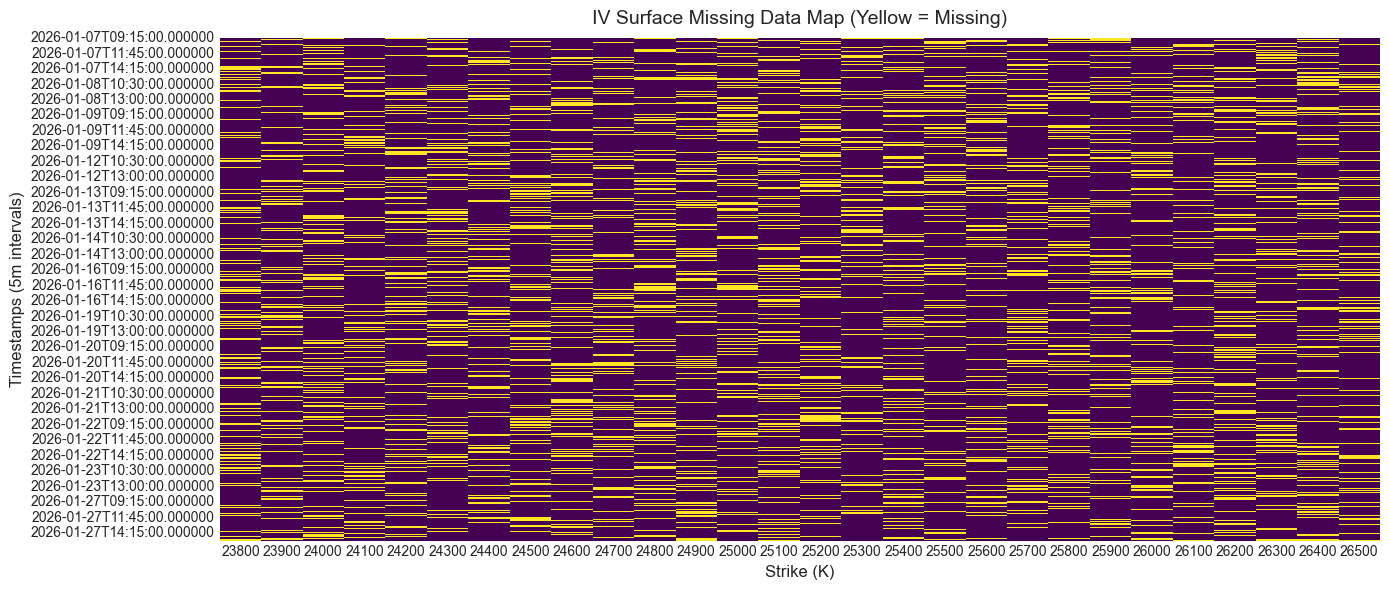

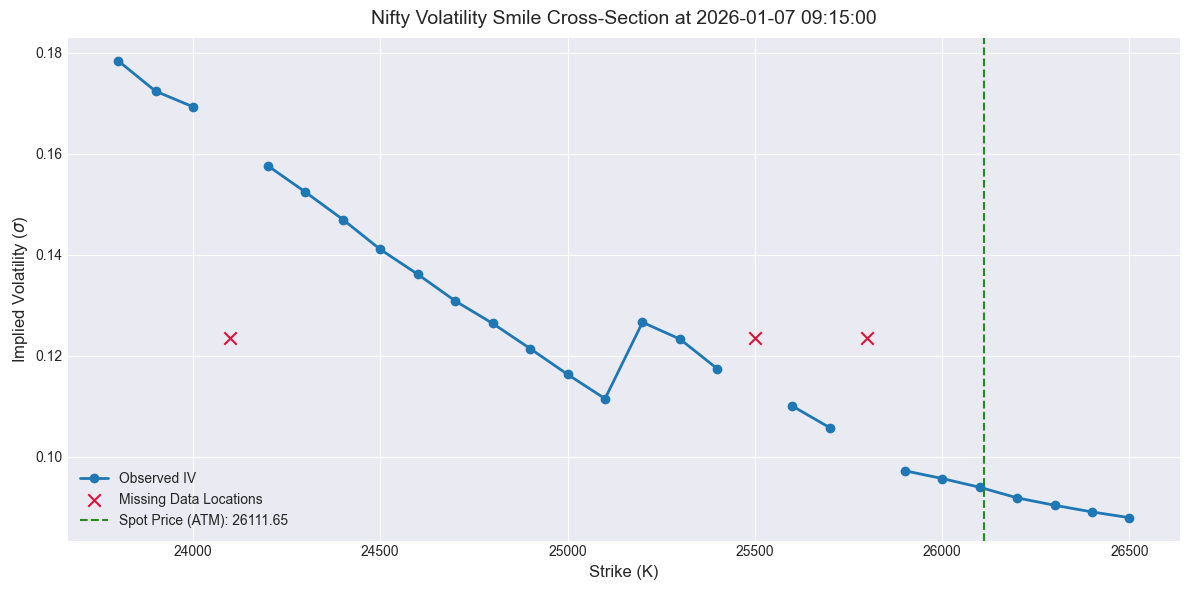

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

# 1. Map out where the data is actually dropping
# Pivoting back to T x K (Time x Strike) purely to spot structural liquidity gaps
iv_matrix = df_surface.pivot(index='datetime', columns='strike', values='implied_volatility')

plt.figure(figsize=(14, 6))
sns.heatmap(iv_matrix.isna(), cbar=False, cmap='viridis')
plt.title('IV Surface Missing Data Map (Yellow = Missing)', fontsize=14, pad=10)
plt.xlabel('Strike (K)', fontsize=12)
plt.ylabel('Timestamps (5m intervals)', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Check the cross-sectional geometry (Volatility Smile)
# Grab the first timestamp (t0) to see the surface shape and where it breaks
t0 = df_surface['datetime'].iloc[0]
smile = df_surface[df_surface['datetime'] == t0].copy()
atm_spot = smile['underlying_price'].iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(smile['strike'], smile['implied_volatility'], 
         marker='o', linestyle='-', color='#1f77b4', lw=2, label='Observed IV')

# Flag the strikes that dropped out at this timestamp to check if it's an OTM/ITM issue
dropped_strikes = smile[smile['implied_volatility'].isna()]['strike']
plt.scatter(dropped_strikes, [smile['implied_volatility'].mean()] * len(dropped_strikes), 
            color='crimson', marker='x', s=80, zorder=5, label='Missing Data Locations')

# Mark the ATM point 
plt.axvline(x=atm_spot, color='forestgreen', linestyle='--', 
            label=f'Spot Price (ATM): {atm_spot:.2f}')

plt.title(f'Nifty Volatility Smile Cross-Section at {t0}', fontsize=14, pad=10)
plt.xlabel('Strike (K)', fontsize=12)
plt.ylabel('Implied Volatility ($\sigma$)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. DEFINE VALIDATION FUNCTIONS LOCALLY
# ==========================================
def create_local_validation_set(df_surface: pd.DataFrame, mask_fraction: float = 0.10, random_seed: int = 42):
    np.random.seed(random_seed)
    
    # Identify rows where we actually know the true IV
    known_mask = df_surface['implied_volatility'].notna()
    known_indices = df_surface[known_mask].index
    
    # Randomly select 10% of these known indices to hide
    num_to_hide = int(len(known_indices) * mask_fraction)
    hidden_indices = np.random.choice(known_indices, size=num_to_hide, replace=False)
    
    df_test = df_surface.copy()
    ground_truth = df_test.loc[hidden_indices, 'implied_volatility'].copy()
    
    # Artificially mask the data to create our testing ground
    df_test.loc[hidden_indices, 'implied_volatility'] = np.nan
    
    return df_test, hidden_indices, ground_truth

def calculate_score(predictions: pd.Series, ground_truth: pd.Series):
    return mean_squared_error(ground_truth, predictions)


# ==========================================
# 2. RUN BASELINE 1: TEMPORAL FORWARD FILL
# ==========================================
# Create the local testing ground
df_local_test, hidden_idx, true_values = create_local_validation_set(df_surface, mask_fraction=0.10)

print(f"Total True Missing Values to submit to Kaggle: {df_surface['implied_volatility'].isna().sum()}")
print(f"Artificially Hidden Values for Local Testing: {len(hidden_idx)}")

# Group by strike, and fill missing values with the last known observation
df_baseline = df_local_test.copy()
df_baseline['implied_volatility'] = df_baseline.groupby('strike')['implied_volatility'].ffill()

# Extract predictions for the indices we artificially hid
ffill_predictions = df_baseline.loc[hidden_idx, 'implied_volatility']

# Forward fill will fail if the very first row of a strike is missing. 
# We drop those few unfillable NaNs just to get a clean baseline score.
valid_mask = ffill_predictions.notna()
baseline_mse = calculate_score(ffill_predictions[valid_mask], true_values[valid_mask])

print(f"\n--- Baseline Model 1 (Temporal Forward Fill) ---")
print(f"Local Validation MSE: {baseline_mse:.6f}")

Total True Missing Values to submit to Kaggle: 5460
Artificially Hidden Values for Local Testing: 2184

--- Baseline Model 1 (Temporal Forward Fill) ---
Local Validation MSE: 0.000630


In [17]:
from scipy.interpolate import interp1d

# ==========================================
# BASELINE 2: Cross-Sectional Flat-Tail Interpolation
# ==========================================
df_baseline2 = df_local_test.copy()

def interpolate_smile(group):
    # Only train the interpolator on physically observed values
    known = group.dropna(subset=['implied_volatility'])
    
    # If a timestamp has completely collapsed (less than 2 points), skip it
    if len(known) < 2:
        return group['implied_volatility']
        
    known = known.sort_values('strike')
    
    # Extract the extreme left and right known volatilities for flat extrapolation
    left_tail_iv = known['implied_volatility'].iloc[0]
    right_tail_iv = known['implied_volatility'].iloc[-1]
    
    # Build the interpolator: Linear in the middle, Flat on the wings
    f = interp1d(
        known['strike'], 
        known['implied_volatility'], 
        kind='linear', 
        bounds_error=False, 
        fill_value=(left_tail_iv, right_tail_iv)
    )
    
    # Reconstruct the entire smile for this timestamp
    return pd.Series(f(group['strike']), index=group.index)

# Apply the mathematical filling timestamp by timestamp
df_baseline2['implied_volatility'] = df_baseline2.groupby('datetime', group_keys=False).apply(interpolate_smile)

# Extract predictions for the artificially hidden indices
cross_predictions = df_baseline2.loc[hidden_idx, 'implied_volatility']
valid_mask_2 = cross_predictions.notna()

baseline2_mse = calculate_score(cross_predictions[valid_mask_2], true_values[valid_mask_2])

print(f"--- Baseline Model 1 (Temporal Forward Fill) ---")
print(f"Local Validation MSE: {baseline_mse:.6f}\n")

print(f"--- Baseline Model 2 (Cross-Sectional Interpolation) ---")
print(f"Local Validation MSE: {baseline2_mse:.6f}")

# Calculate the exact improvement percentage
improvement = ((baseline_mse - baseline2_mse) / baseline_mse) * 100
print(f"Improvement over Temporal Fill: {improvement:.2f}%")

--- Baseline Model 1 (Temporal Forward Fill) ---
Local Validation MSE: 0.000630

--- Baseline Model 2 (Cross-Sectional Interpolation) ---
Local Validation MSE: 0.000287
Improvement over Temporal Fill: 54.43%


In [19]:
import xgboost as xgb

# ==========================================
# BASELINE 3: Multidimensional XGBoost Regressor
# ==========================================
df_ml = df_local_test.copy()

# --- FEATURE ENGINEERING ---
# 1. Time to Expiry (in days)
df_ml['days_to_expiry'] = (df_ml['expiry'] - df_ml['datetime']).dt.total_seconds() / (24 * 3600)

# 2. Option Type Encoding (CE = 1, PE = 0)
df_ml['is_call'] = (df_ml['option_type'] == 'CE').astype(int)

# 3. Strict Temporal Lag (No Lookahead Bias)
# We shift by 1 to strictly look at the PAST timestamp, then forward fill missing gaps
df_ml['iv_lag1'] = df_ml.groupby('strike')['implied_volatility'].transform(lambda x: x.shift(1).ffill())

# Define our feature matrix
features = ['strike', 'underlying_price', 'moneyness', 'days_to_expiry', 'is_call', 'iv_lag1']
target = 'implied_volatility'

# --- TRAIN / TEST SPLIT ---
# The Kaggle hidden data is already represented as NaNs in df_local_test.
# Therefore, our training set is every row that actually has a known IV.
train_mask = df_ml['implied_volatility'].notna()
X_train = df_ml.loc[train_mask, features]
y_train = df_ml.loc[train_mask, target]

# Our test set is strictly the indices we artificially hid
X_test = df_ml.loc[hidden_idx, features]
y_test = true_values

# Drop the very first row for each strike since iv_lag1 will be NaN
valid_train = X_train['iv_lag1'].notna()
X_train_clean = X_train[valid_train]
y_train_clean = y_train[valid_train]

# --- MODEL TRAINING ---
print("Training XGBoost Regressor...")
model = xgb.XGBRegressor(
    n_estimators=150, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42, 
    objective='reg:squarederror'
)

model.fit(X_train_clean, y_train_clean)

# --- PREDICTION & EVALUATION ---
ml_preds = model.predict(X_test)

# Calculate final local score
ml_mse = calculate_score(ml_preds, y_test)

print(f"\n--- Model 3 (XGBoost Regressor) ---")
print(f"Local Validation MSE: {ml_mse:.6f}")

# Compare to our best baseline
improvement_ml = ((baseline2_mse - ml_mse) / baseline2_mse) * 100
print(f"Improvement over Cross-Sectional Spline: {improvement_ml:.2f}%")

# Feature Importance Check
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop 3 Feature Importances:")
print(importance.head(3))

Training XGBoost Regressor...

--- Model 3 (XGBoost Regressor) ---
Local Validation MSE: 0.000278
Improvement over Cross-Sectional Spline: 3.25%

Top 3 Feature Importances:
iv_lag1             0.853507
days_to_expiry      0.096638
underlying_price    0.037421
dtype: float32


In [22]:
# ==========================================
# FINAL PHASE: KAGGLE PIPELINE
# ==========================================
import pandas as pd
import xgboost as xgb

print("1. Retraining XGBoost Model...")
train_mask_full = df_ml['implied_volatility'].notna()
X_train_full = df_ml.loc[train_mask_full, features]
y_train_full = df_ml.loc[train_mask_full, target]

valid_train_full = X_train_full['iv_lag1'].notna()
X_train_full = X_train_full[valid_train_full]
y_train_full = y_train_full[valid_train_full]

final_model = xgb.XGBRegressor(
    n_estimators=150, learning_rate=0.05, max_depth=6, 
    random_state=42, objective='reg:squarederror'
)
final_model.fit(X_train_full, y_train_full)

print("2. Predicting the hidden targets...")
actual_missing_mask = df_surface['implied_volatility'].isna()
X_missing = df_ml.loc[actual_missing_mask, features]
predictions = final_model.predict(X_missing)

print("3. Building O(1) Exact Mapping Dictionary...")
df_missing_subset = df_surface[actual_missing_mask].copy()
df_missing_subset['predicted_iv'] = predictions

# Reconstruct the exact column names (e.g., NIFTY27JAN2625200CE)
df_missing_subset['instrument'] = 'NIFTY' + df_missing_subset['expiry'].dt.strftime('%d%b%y').str.upper() + df_missing_subset['strike'].astype(str) + df_missing_subset['option_type']

# Ensure the datetime strings exactly match the original CSV
df_missing_subset['datetime_str'] = df_missing_subset['datetime'].dt.strftime('%d-%m-%Y %H:%M')

# Create a dictionary mapping: (Timestamp, Instrument) -> Predicted IV
prediction_dict = df_missing_subset.set_index(['datetime_str', 'instrument'])['predicted_iv'].to_dict()

print("4. Patching the Original Dataset directly in memory...")
original_df = pd.read_csv('../data/dataset.csv')
filled_df = original_df.copy()

feature_cols = [c for c in original_df.columns if c not in ["datetime", "underlying_price"]]

for col in feature_cols:
    missing_mask = original_df[col].isna()
    for idx in original_df[missing_mask].index:
        dt_str = original_df.loc[idx, "datetime"]
        
        # look up exact coordinate
        key = (dt_str, col)
        if key in prediction_dict:
            filled_df.loc[idx, col] = prediction_dict[key]

filled_df.to_csv('../data/filled_dataset.csv', index=False)

print("5. Running Finance Club Submission Converter...")
SEPARATOR = "||"
rows = []
for col in feature_cols:
    was_missing = original_df[col].isna()
    for idx in original_df.index[was_missing]:
        dt  = original_df.loc[idx, "datetime"]
        uid = f"{dt}{SEPARATOR}{col}"
        val = filled_df.loc[idx, col]
        rows.append({"id": uid, "value": val})

solution = pd.DataFrame(rows, columns=["id", "value"])
solution = solution.sort_values("id").reset_index(drop=True)

output_path = '../submissions/submission_v2.csv'
solution.to_csv(output_path, index=False)
print(f"✅ BULLETPROOF SUBMISSION READY -> {output_path} ({len(solution)} rows)")

1. Retraining XGBoost Model...
2. Predicting the hidden targets...
3. Building O(1) Exact Mapping Dictionary...
4. Patching the Original Dataset directly in memory...
5. Running Finance Club Submission Converter...
✅ BULLETPROOF SUBMISSION READY -> ../submissions/submission_v2.csv (5460 rows)
